In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("Cars Dataset.csv")

In [3]:
df.head()

,Model,Year,Km/h,Color,Type,Fuel,Price
0,Hyundai Elantra HD,2009.0,"165,000",Gray,Automatic,Gasoline,"560,000"
1,Hyundai Elantra,2010.0,"194,000",Black,Automatic,Gasoline,"600,000"
2,Hyundai Elantra HD,2010.0,"205,000",Silver,Automatic,Gasoline,"575,000"
3,Hyundai Elantra,2010.0,"160,000",Black,Automatic,Gasoline,"550,000"
4,Hyundai Elantra,2009.0,"140,451",Eggplant,Automatic,Gasoline,"650,000"


In [4]:
df.shape

(957, 7)

In [5]:
df.describe()

,Year
count,599.000000
mean,2048.323873
std,743.895065
min,2008.000000
25%,2014.000000
50%,2019.000000
75%,2022.000000
max,20224.000000


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 957 entries, 0 to 956
Data columns (total 7 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Model   599 non-null    object 
 1   Year    599 non-null    float64
 2    Km/h   599 non-null    object 
 3   Color   599 non-null    object 
 4   Type    599 non-null    object 
 5   Fuel    599 non-null    object 
 6   Price   599 non-null    object 
dtypes: float64(1), object(6)
memory usage: 52.5+ KB


In [7]:
print(df["Year"].unique())

[ 2009.  2010.  2012.  2011.  2014.  2013.  2018.  2019.  2022.  2023.
  2015.  2016.  2020.  2017.  2024.  2021.  2025.  2008. 20224.    nan]


In [8]:
df['Year'].isna()

0      False
1      False
2      False
3      False
4      False
       ...  
952     True
953     True
954     True
955     True
956     True
Name: Year, Length: 957, dtype: bool

In [9]:
df = df.dropna(subset=["Year"])
df["Year"] = df["Year"].replace(20224, 2024)
df["Year"] = df["Year"].astype(int)

In [10]:
print(df["Year"].unique())

[2009 2010 2012 2011 2014 2013 2018 2019 2022 2023 2015 2016 2020 2017
 2024 2021 2025 2008]


In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 599 entries, 0 to 598
Data columns (total 7 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   Model   599 non-null    object
 1   Year    599 non-null    int64 
 2    Km/h   599 non-null    object
 3   Color   599 non-null    object
 4   Type    599 non-null    object
 5   Fuel    599 non-null    object
 6   Price   599 non-null    object
dtypes: int64(1), object(6)
memory usage: 37.4+ KB


In [12]:
print(df.isnull().sum())

Model     0
Year      0
 Km/h     0
Color     0
Type      0
Fuel      0
Price     0
dtype: int64


In [13]:
df[" Km/h "] = df[" Km/h "].str.replace(",", "").astype(int)
df["Price"] = df["Price"].str.replace(",", "").astype(int)

In [14]:
print(df.columns.tolist())

['Model', 'Year', ' Km/h ', 'Color', 'Type', 'Fuel', 'Price']


In [15]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 599 entries, 0 to 598
Data columns (total 7 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   Model   599 non-null    object
 1   Year    599 non-null    int64 
 2    Km/h   599 non-null    int64 
 3   Color   599 non-null    object
 4   Type    599 non-null    object
 5   Fuel    599 non-null    object
 6   Price   599 non-null    int64 
dtypes: int64(3), object(4)
memory usage: 37.4+ KB


In [16]:
df.rename(columns={' Km/h ': 'Km/h'}, inplace=True)

In [17]:
print(df.columns.tolist())

['Model', 'Year', 'Km/h', 'Color', 'Type', 'Fuel', 'Price']


In [18]:
df.isnull().sum()

Model    0
Year     0
Km/h     0
Color    0
Type     0
Fuel     0
Price    0
dtype: int64

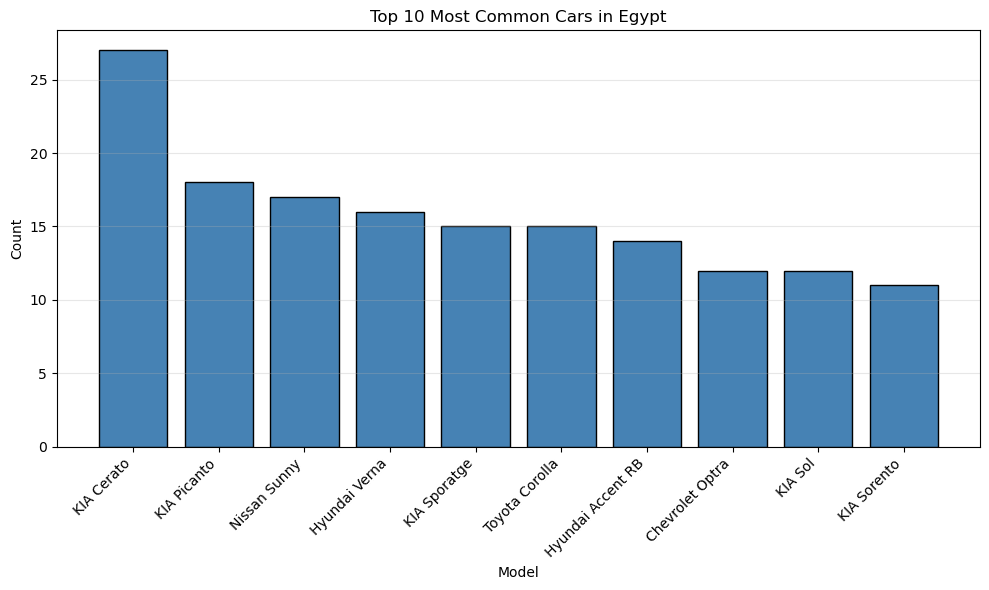

In [19]:
top10 = df["Model"].value_counts().head(10)

plt.figure(figsize=(10, 6))
plt.bar(top10.index, top10.values, color='steelblue', edgecolor='black')
plt.xlabel('Model')
plt.ylabel('Count')
plt.title('Top 10 Most Common Cars in Egypt')
plt.xticks(rotation=45, ha='right')
plt.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

# Insight
Kia Cerato is the most common car in the Egyptian used car market, 
reflecting its popularity due to affordability and wide availability of spare parts.

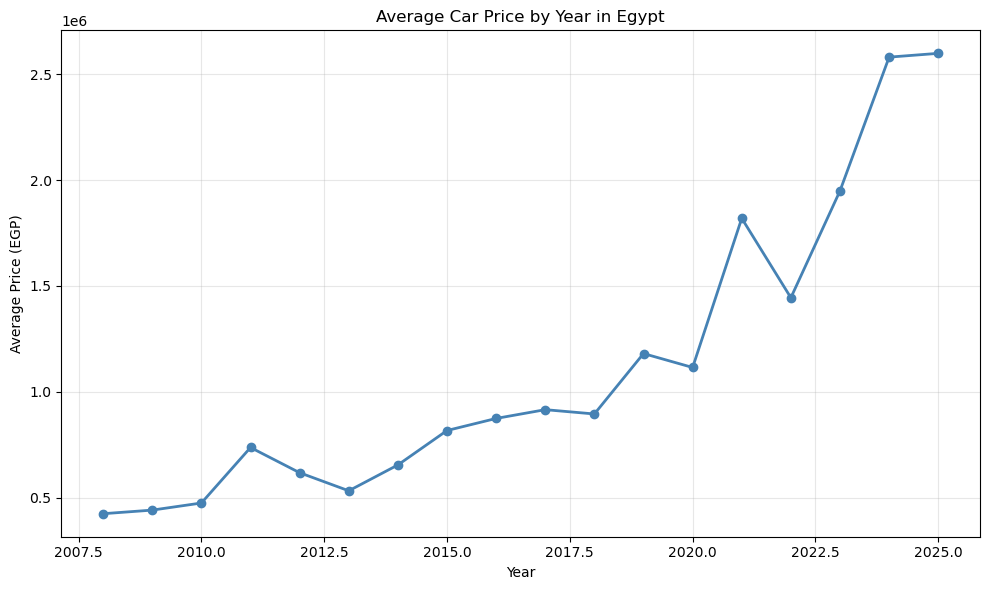

In [20]:
avg_price_by_year = df.groupby("Year")["Price"].mean()

plt.figure(figsize=(10, 6))
plt.plot(avg_price_by_year.index, avg_price_by_year.values, 
         color='steelblue', marker='o', linewidth=2)
plt.xlabel('Year')
plt.ylabel('Average Price (EGP)')
plt.title('Average Car Price by Year in Egypt')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Insight
Car prices show a general upward trend with newer models, 
which aligns with inflation and increasing import costs in Egypt.

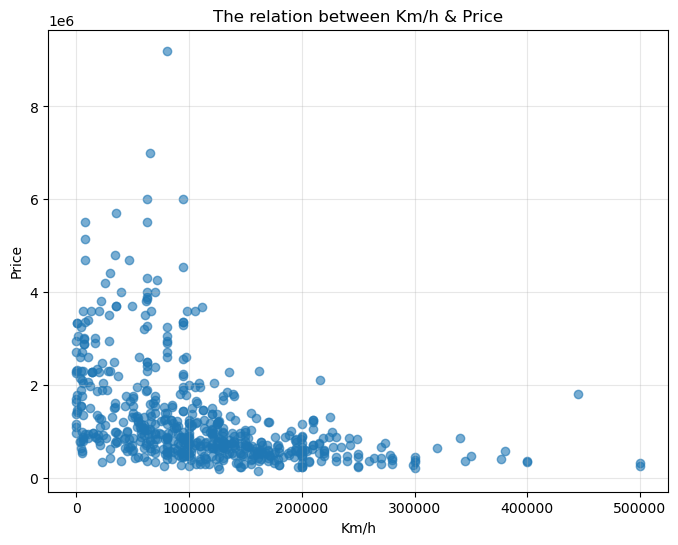

In [21]:
plt.figure(figsize = (8, 6))
plt.scatter(df["Km/h"], df["Price"], alpha=.6)

plt.xlabel('Km/h')
plt.ylabel('Price')
plt.title('The relation between Km/h & Price')

plt.grid(True, alpha=.3)
plt.show()

# Insight
Higher mileage does not strongly predict lower prices on its own.
Data points are clustered closely together, suggesting that other factors 
such as car model and manufacturing year play a more significant role in determining price.

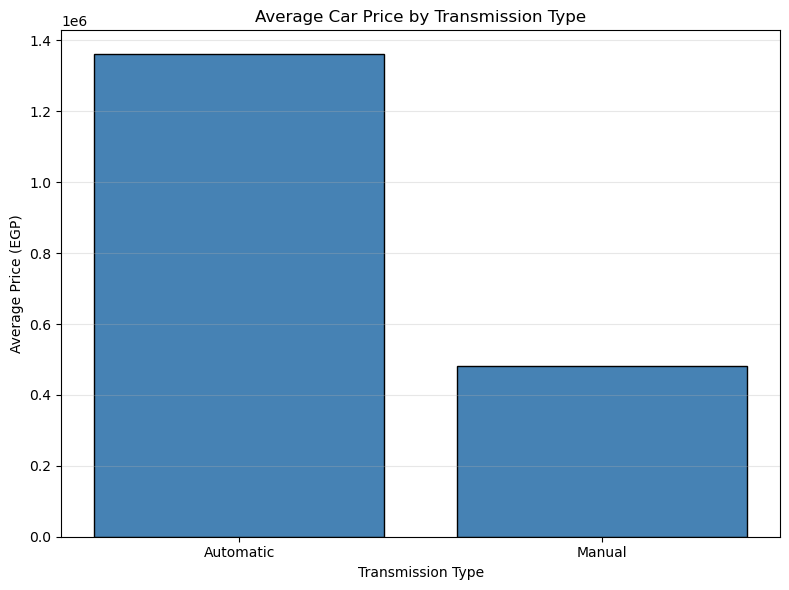

In [22]:
avg_price_by_type = df.groupby("Type")["Price"].mean()

plt.figure(figsize=(8, 6))
plt.bar(avg_price_by_type.index, avg_price_by_type.values, 
        color='steelblue', edgecolor='black')
plt.xlabel('Transmission Type')
plt.ylabel('Average Price (EGP)')
plt.title('Average Car Price by Transmission Type')
plt.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

# Insight
Automatic transmission cars are priced significantly higher than manual ones,
reflecting higher demand for automatic cars in the Egyptian market.

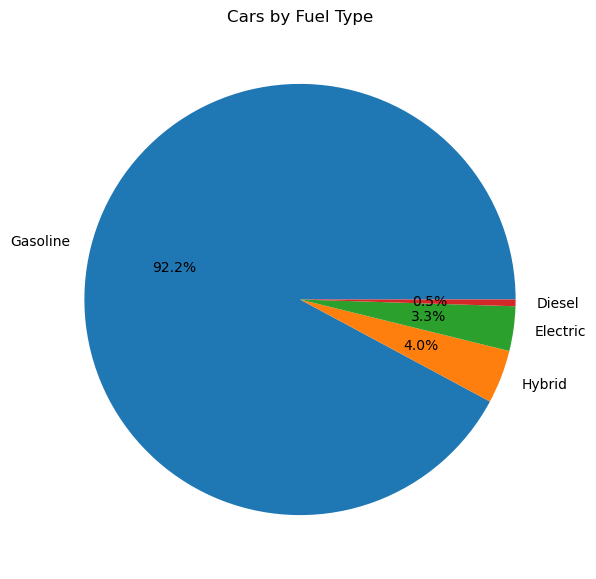

In [23]:
fuel_counts = df["Fuel"].value_counts()

plt.figure(figsize=(7, 7))
plt.pie(fuel_counts.values, labels=fuel_counts.index, autopct='%1.1f%%')
plt.title('Cars by Fuel Type')
plt.show()

# Insight
Gasoline powered cars dominate the market by a large margin,
with other fuel types (diesel, electric, hybrid) representing a minimal share.

In [24]:
df.to_csv("cars_dataset_traning.csv", index = True)